In [ ]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic


load_dotenv()

llm = ChatAnthropic(model= 'claude-sonnet-4-20250514')

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [ ]:
query = '대손충당금에 대해서 설명해주세요'

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]     

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [ ]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

In [ ]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [ ]:
graph = graph_builder.compile()

In [ ]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

In [ ]:
graph.invoke(initial_state)

{'messages': [AIMessage(content='대손충당금(貸損充當金, Allowance for Bad Debts)에 대해 자세히 설명드리겠습니다.\n\n## 1. 대손충당금의 개념\n\n**대손충당금**은 기업이 보유한 매출채권(외상매출금, 받을어음 등) 중 회수가 불가능할 것으로 예상되는 금액에 대해 미리 설정해두는 충당금입니다.\n\n## 2. 설정 목적\n\n- **보수주의 원칙** 적용: 미래 손실을 미리 반영\n- **재무제표의 신뢰성** 제고\n- **매출채권의 실질가치** 표시\n- **기간 대응원칙** 실현\n\n## 3. 설정 방법\n\n### 가. 개별평가법\n- 개별 채권별로 회수 가능성 검토\n- 대규모 채권에 적용\n\n### 나. 총괄평가법\n```\n대손충당금 = 매출채권 잔액 × 대손율\n```\n- 과거 대손 경험률 활용\n- 채권 연령별 차등 적용\n\n## 4. 회계처리\n\n### 가. 대손충당금 설정\n```\n(차) 대손상각비         xxx\n    (대) 대손충당금          xxx\n```\n\n### 나. 실제 대손 발생\n```\n(차) 대손충당금         xxx\n    (대) 매출채권            xxx\n```\n\n### 다. 상각채권 회수\n```\n(차) 매출채권           xxx\n    (대) 대손충당금회입       xxx\n\n(차) 현금               xxx\n    (대) 매출채권            xxx\n```\n\n## 5. 재무제표 표시\n\n**재정상태표**에서:\n```\n매출채권                1,000,000\n차감: 대손충당금          (50,000)\n매출채권 순액             950,000\n```\n\n## 6. 세무상 취급\n\n- **법인세법상** 손금인정 기준이 별도로 존재\n- 회계상 설정액과 세무상 인정액 차이 발생 가능\n- 일시차이로 인한 이연법인세 인식 필요\n\n## 7.

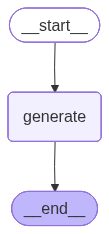

In [ ]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## 데이터 전처리

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
from pyzerox import zerox
import os
import asyncio
from dotenv import load_dotenv

load_dotenv()

# Anthropic API 키 설정 확인
# .env 파일에 ANTHROPIC_API_KEY=your-api-key 가 있어야 함

# 모델 설정
model = "claude-sonnet-4-20250514"  # 또는 다른 Claude 모델

# 커스텀 시스템 프롬프트 (필요시)
custom_system_prompt = None

async def main():
    file_path = "Tax.pdf"
    select_pages = None  # 전체 페이지
    output_dir = "./output_test"
    
    result = await zerox(
        file_path=file_path,
        model=model,
        output_dir=output_dir,
        custom_system_prompt=custom_system_prompt,
        select_pages=select_pages
    )
    return result

# 실행
result = asyncio.run(main())
print(result)

## database load

In [2]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import Docx2txtLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
import shutil

# 1. 문서 로드
loader = Docx2txtLoader('Tax_with_table.docx')
documents = loader.load()

# 2. 텍스트 분할 (청킹)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
splits = text_splitter.split_documents(documents)

In [ ]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma

embedding = UpstageEmbeddings(model="solar-embedding-1-large")


# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

In [9]:
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={'k': 15, 'fetch_k': 50}
)

In [10]:
query = '원천징수되는 기타소득에 관하여 설명하시오'

retriever.invoke(query)

[Document(metadata={'source': 'Tax_with_table.docx'}, page_content='② 원천징수의무자가 12월분의 연말정산 사업소득을 다음 연도 2월 말일까지 지급하지 아니한 경우에는 다음 연도 2월 말일에 그 사업소득을 지급한 것으로 보아 소득세를 원천징수한다.\n\n[본조신설 2010. 12. 27.]\n\n\n\n제5관 기타소득에 대한 원천징수 <개정 2009. 12. 31.>\n\n\n\n제145조(기타소득에 대한 원천징수시기와 방법 및 원천징수영수증의 발급) ① 원천징수의무자가 기타소득을 지급할 때에는 그 기타소득금액에 원천징수세율을 적용하여 계산한 소득세를 원천징수한다.\n\n② 기타소득을 지급하는 원천징수의무자는 이를 지급할 때에 그 기타소득의 금액과 그 밖에 필요한 사항을 적은 재정경제부령으로 정하는 원천징수영수증을 그 소득을 받는 사람에게 발급하여야 한다. 다만, 제21조제1항제15호가목 및 제19호가목ㆍ나목에 해당하는 기타소득으로서 대통령령으로 정하는 금액 이하를 지급할 때에는 지급받는 자가 원천징수영수증의 발급을 요구하는 경우 외에는 발급하지 아니할 수 있다.<개정 2010. 12. 27., 2025. 10. 1.>\n\n[전문개정 2009. 12. 31.]\n\n[제목개정 2010. 12. 27.]\n\n\n\n제145조의2(기타소득 원천징수시기에 대한 특례) 「법인세법」 제67조에 따라 처분되는 기타소득에 대한 소득세의 원천징수시기에 관하여는 제131조제2항을 준용한다.\n\n[본조신설 2010. 12. 27.]\n\n\n\n제145조의3(종교인소득에 대한 연말정산 등) ① 종교인소득을 지급하고 그 소득세를 원천징수하는 자는 해당 과세기간의 다음 연도 2월분의 종교인소득을 지급할 때(2월분의 종교인소득을 2월 말일까지 지급하지 아니하거나 2월분의 종교인소득이 없는 경우에는 2월 말일로 한다. 이하 이 조에서 같다) 또는 해당 종교관련종사자와의 소속관계가 종료되는 달의 종교인소득을 지급할 때 해당 과세